<a href="https://colab.research.google.com/github/natenorris10/MAT-422/blob/main/HW_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Probability Homework 2.3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal

###2.3.1 - Joint Probability Distributions

We start with the discrete case.  Let X and Y be two discrete random variables defined on the sample space S of an experiment.  Then the joint probability mass function is defined as:  
$p(x,y) = \mathbb{P}(X = x, Y = y)$, for each pair $(x, y)$.

Like all probability mass functions, it must be the case that $p(x,y) \ge 0,$ and $∑_x ∑_y p(x,y) = 1$.

The marginal probability mass function of $X$ is mathematically written as $p_X(x) = \sum\limits_{y:p(x,y) > 0} p(x,y)$ for each possible value of $x$.  The definition is similar for the random variable $Y$, written like
$p_Y(y) = \sum\limits_{x:p(x,y) > 0} p(x,y)$ for each possible value $y$.

In [ ]:
# Discrete case

                    # Y = 0  Y = 1
joint_pmf = np.array([[0.10, 0.50],     # X = 0
                      [0.20, 0.15],     # X = 1
                      [0.30, 0.20]])    # X = 2

# Marginals
p_x = joint_pmf.sum(axis=1)
p_y = joint_pmf.sum(axis=0)

print("Marginal of X: ", p_x)
print("Marginal of Y: ", p_y)


Marginal of X:  [0.6  0.35 0.5 ]
Marginal of Y:  [0.6  0.85]


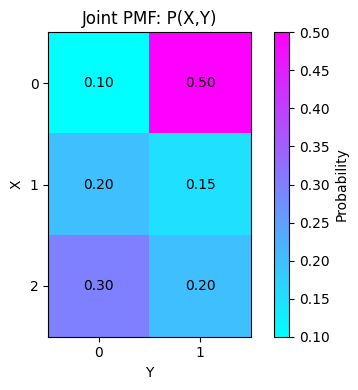

In [ ]:
# Heatmap of Discrete case

disc_xvals = [0, 1, 2]
disc_yvals = [0, 1]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(joint_pmf, cmap='cool', origin='upper')

ax.set_xticks(range(len(disc_yvals)))
ax.set_xticklabels(disc_yvals)
ax.set_yticks(range(len(disc_xvals)))
ax.set_yticklabels(disc_xvals)
ax.set_xlabel('Y')
ax.set_ylabel('X')
ax.set_title('Joint PMF: P(X,Y)')

for i in range(len(disc_xvals)):
  for j in range(len(disc_yvals)):
    ax.text(j, i, f"{joint_pmf[i, j]:.2f}", ha='center', va='center',
            color='black')

fig.colorbar(im, label='Probability')
plt.tight_layout()
plt.show()

Now onto the continuous case.  Let $X$ and $Y$ be two continous random variables.  The joint density function of these variables $f(x,y)$ satisfies the conditions $f(x,y) \ge 0$ and
${\large ∫}_{\small-∞}^{\small∞} {\large ∫}_{\small-∞}^{\small∞} f(x,y)dxdy = 1.$  Then for any two-dimensional set $A$, we have $\mathbb{P}[(X, Y) \in A] = {\large ∫∫}_A f(x,y)dxdy$.


The marginal pdf's for $X$ and $Y$, written as $f_X(x)$ and $f_Y(y)$ respectively, are defined as <br>
$f_X(x)= {\large∫}_{-∞}^∞ f(x,y)dxdy$ for $-∞ < x < ∞$ <br>
$f_Y(y)= {\large∫}_{-∞}^∞ f(x,y)dxdy$ for $-∞ < y < ∞$

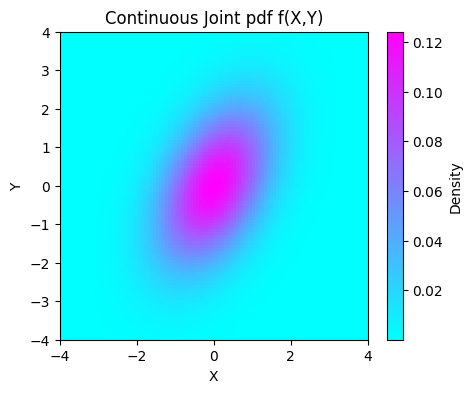

In [ ]:
# Continous case

mean = [0, 0]
cov = [[1.0, 0.6],
       [0.6, 2.0]]
rv = multivariate_normal(mean=mean, cov=cov)

cont_xvals = np.linspace(-4, 4, 100)
cont_yvals = np.linspace(-4, 4, 100)
cont_X, cont_Y = np.meshgrid(cont_xvals, cont_yvals)

pos = np.dstack((cont_X, cont_Y))
Z = rv.pdf(pos)

# Heatmap

fig, ax = plt.subplots(figsize=(5, 4))
cont_im = ax.imshow(Z, extent=[-4, 4, -4, 4], origin='lower', cmap='cool')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Continuous Joint pdf f(X,Y)')
fig.colorbar(cont_im, label='Density')
plt.show()


###2.3.2 - Correlation and Dependence

Correlation is a useful way to determine how two random variables interact with each other.  The Covariance is a measure two random variable's joint variability.

Let $X, Y$ be two joint random variables that are either discrete or continuous.  The covariance between these two is given by: <br>
$Cov(X,Y) = \mathbb{E}[(X - μ_X)(Y - μ_Y)]$ <br>
$ = \begin{cases} ∑_x ∑_y (x-μ_X)(y-μ_Y)p(x,y), \text{ for } X,Y \text{ discrete} \\ ∫_{-∞}^∞ ∫_{-∞}^∞ (x-μ_X)(y-μ_Y)f(x,y), \text{ for } X,Y \text{ continuous} \end{cases}$

The correlation coefficient is a measure of the linear relationship between two random variables.  It is given by <br>
$ρ_{X,Y} = \dfrac{Cov(X,Y)}{\sigma_X \cdot \sigma_Y}$ <br>
<br>
Sometimes this is just denoted by $ρ$ or $Corr(X,Y)$

We can also have a sample correlation coefficient, which represents the linear relationship between paired data $(x_i, y_i)$.  The sample correlation coefficient is written as: <br>
$r_{xy} = \dfrac{∑_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{∑_{i=1}^n (x_i - \bar{x})^2} \sqrt{∑_{i=1}^n (y_i - \bar{y})^2}}$

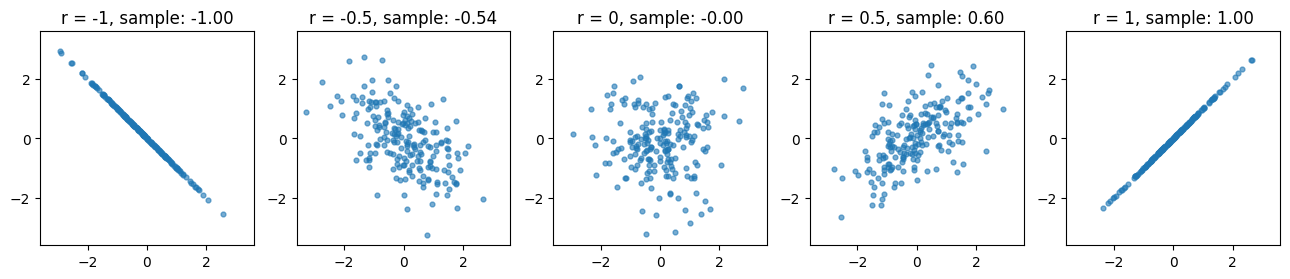

In [ ]:
# Examples of Correlation plots

rng = np.random.default_rng(10)
n_corr = 200
r_values = [-1, -0.5, 0, 0.5, 1]

fig, axes = plt.subplots(1, 5, figsize=(16, 3.6))

for ax, r in zip(axes, r_values):
  x = rng.standard_normal(n_corr)
  noise = rng.standard_normal(n_corr)

  y = r * x + np.sqrt(1 - r**2) * noise
  actual_r = np.corrcoef(x, y)[0, 1]

  ax.scatter(x, y, s=12, alpha=0.6)
  ax.set_title(f'r = {r}, sample: {actual_r:.2f}')
  ax.set_xlim(-3.6, 3.6)
  ax.set_ylim(-3.6, 3.6)
  ax.set_aspect('equal')


###2.3.3 - Random Samples

A simple random sample is just a subset of a population that is randomly gathered for analysis.  The random variables $X_1, X_2, ..., X_n,$ are said to form a (simple) random sample  fo size $n$ if the following two conditions hold: <br>
1. The $X_i$'s are independent random variables
2. Every $X_i$ has the same probability distribution

The Central Limit Theorem is a core of probability, and extends from random sampling.  Basically, after a normalization procedure, any set of independent random variables that come from any particular distribution will then follow the normal distribution.  This is incredibly important in probability and statistics because through this method we can utilize the common characteristics of a normal distribution to help describe our data, even if the data itself isn't normally distributed.

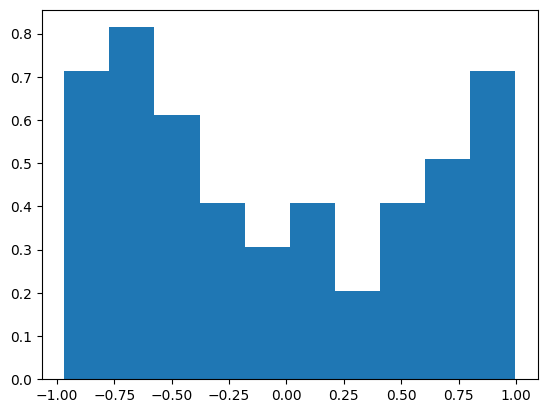

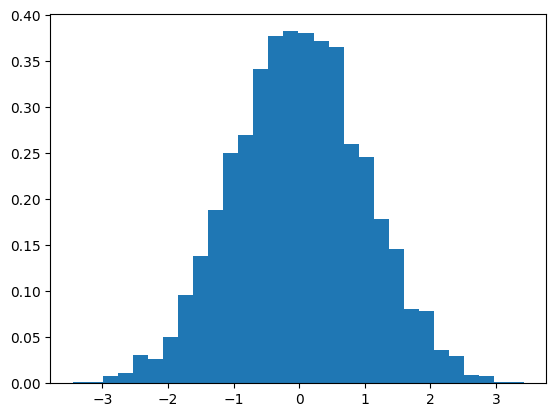

In [ ]:
# CLT at work

unif_sample = rng.uniform(low=-1.0, high=1.0, size=50)
sample_means = np.array([rng.uniform(low=-1.0, high=1.0, size=50).mean()
                        for _ in range(5000)])



normalized_means = (sample_means - sample_means.mean()) / sample_means.std()

# Original Sample
plt.hist(unif_sample, density=True)
plt.show()
# CLT
plt.hist(normalized_means, bins=30, density=True)
plt.show()